# 05. Isolation Forest 기반 이상탐지 모델

이 노트북은 04에서 확정한 anomaly feature를 사용해 Isolation Forest baseline을 학습한다.

목표는 단순 실행이 아니라 이상탐지 성능을 최대한 끌어올리는 것이다. 학습은 `normal` 데이터만 사용하고, validation의 `normal`/`pre_fault` 라벨로 feature cutoff, threshold, hyperparameter를 선택한다.

In [1]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, precision_recall_fscore_support, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / ".git").exists() and (path / "pyproject.toml").exists():
            return path
    raise RuntimeError("프로젝트 루트를 찾지 못했습니다. C:/project3.0_2 안에서 노트북을 실행하세요.")


ROOT = find_project_root(Path.cwd().resolve())
FEATURE_DIR = ROOT / "data" / "processed" / "ml_features"
OUT_DIR = ROOT / "data" / "processed" / "ml_baseline"
MODEL_DIR = OUT_DIR / "models"
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TRAINABLE_PATH = FEATURE_DIR / "trainable_windows.csv"
FEATURE_COLUMNS_PATH = FEATURE_DIR / "feature_columns.csv"

print("프로젝트 루트:", ROOT)
print("학습 테이블:", TRAINABLE_PATH)
print("feature 계약:", FEATURE_COLUMNS_PATH)

프로젝트 루트: C:\project3.0_2
학습 테이블: C:\project3.0_2\data\processed\ml_features\trainable_windows.csv
feature 계약: C:\project3.0_2\data\processed\ml_features\feature_columns.csv


## 1. 입력 데이터와 anomaly feature 읽기

In [2]:
if not TRAINABLE_PATH.exists():
    raise FileNotFoundError("04 산출물 trainable_windows.csv가 없습니다. 04_feature_engineering.ipynb를 먼저 실행하세요.")
if not FEATURE_COLUMNS_PATH.exists():
    raise FileNotFoundError("04 산출물 feature_columns.csv가 없습니다. 04_feature_engineering.ipynb를 먼저 실행하세요.")

df = pd.read_csv(TRAINABLE_PATH)
feature_contract = pd.read_csv(FEATURE_COLUMNS_PATH)

def parse_bool_series(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    return series.astype(str).str.lower().isin(["true", "1", "yes"])


anomaly_contract = feature_contract[parse_bool_series(feature_contract["anomaly_feature"])].copy()
anomaly_features_all = anomaly_contract["column"].tolist()

print("전체 행/열:", df.shape)
print("anomaly feature 수:", len(anomaly_features_all))
display(df["label"].value_counts(dropna=False).rename_axis("label").reset_index(name="row_count"))
display(anomaly_contract[["column", "family", "missing_rate"]].head())

전체 행/열: (3270, 175)
anomaly feature 수: 151


,label,row_count
0,normal,1818
1,pre_fault,815
2,unlabeled,637


,column,family,missing_rate
0,day_of_week,시간/주기,0.000000
1,day_of_year,시간/주기,0.000000
2,days_since_last_any_event,이벤트 이력,0.218960
4,days_since_last_task_event,이벤트 이력,0.218960
5,dhw_supply_temperature_gap__last,센서 통계,0.475229


## 2. 실험 설정

- `split_time_based`와 `split_regime_based`를 함께 평가한다.
- 결측률 cutoff별 feature set을 비교한다.
- threshold는 train normal score의 quantile로 정한다.

In [3]:
SPLIT_COLUMNS = [col for col in ["split_time_based", "split_regime_based"] if col in df.columns]
MISSING_CUTOFFS = [1.0, 0.5, 0.4, 0.3]
THRESHOLD_QUANTILES = [0.80, 0.825, 0.85, 0.875, 0.90, 0.925, 0.95, 0.975, 0.99]
MODEL_GRID = [
    {"n_estimators": 300, "max_features": 0.8},
    {"n_estimators": 300, "max_features": 1.0},
    {"n_estimators": 600, "max_features": 0.8},
    {"n_estimators": 600, "max_features": 1.0},
]
RANDOM_STATE = 42
MIN_FEATURES = 40

print("평가 split 후보:", SPLIT_COLUMNS)

평가 split 후보: ['split_time_based', 'split_regime_based']


In [4]:
def as_bool(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    return series.astype(str).str.lower().isin(["true", "1", "yes"])


def to_jsonable(value):
    if isinstance(value, dict):
        return {str(k): to_jsonable(v) for k, v in value.items()}
    if isinstance(value, list):
        return [to_jsonable(v) for v in value]
    if isinstance(value, tuple):
        return [to_jsonable(v) for v in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if not isinstance(value, (list, dict, tuple)):
        try:
            if pd.isna(value):
                return None
        except TypeError:
            pass
    return value


def select_feature_set(cutoff: float) -> list[str]:
    selected = anomaly_contract[anomaly_contract["missing_rate"].fillna(1.0).astype(float) <= cutoff]["column"].tolist()
    return [col for col in selected if col in df.columns]


def split_masks(split_col: str):
    split_values = df[split_col].astype(str).str.lower()
    labels = df["label"].astype(str)

    train_normal = (split_values == "train") & (labels == "normal")
    if "use_for_supervised_training" in df.columns:
        train_normal &= as_bool(df["use_for_supervised_training"])
    if "normal_reference_outlier" in df.columns:
        train_normal &= ~as_bool(df["normal_reference_outlier"])

    validation_eval = (split_values == "validation") & labels.isin(["normal", "pre_fault"])
    holdout_eval = (split_values == "holdout") & labels.isin(["normal", "pre_fault"])
    return train_normal, validation_eval, holdout_eval


def y_binary(mask: pd.Series) -> np.ndarray:
    return (df.loc[mask, "label"].astype(str).values == "pre_fault").astype(int)


def anomaly_score(pipe: Pipeline, frame: pd.DataFrame, features: list[str]) -> np.ndarray:
    return -pipe.decision_function(frame[features])


def metric_row(y_true: np.ndarray, scores: np.ndarray, threshold: float) -> dict:
    pred = (scores >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, pred, average="binary", zero_division=0)
    normal_count = int((y_true == 0).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fpr = fp / normal_count if normal_count else np.nan
    if len(np.unique(y_true)) == 2:
        ap = average_precision_score(y_true, scores)
        auc = roc_auc_score(y_true, scores)
    else:
        ap = np.nan
        auc = np.nan
    return {
        "average_precision": ap,
        "roc_auc": auc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positive_rate": fpr,
    }

## 3. Isolation Forest 실험 실행

In [5]:
experiment_rows = []
fitted_models = {}

for split_col in SPLIT_COLUMNS:
    train_mask, val_mask, holdout_mask = split_masks(split_col)
    y_val = y_binary(val_mask)
    if train_mask.sum() == 0 or val_mask.sum() == 0 or len(np.unique(y_val)) < 2:
        print("건너뜀:", split_col, "train_normal", int(train_mask.sum()), "validation", int(val_mask.sum()))
        continue

    for cutoff in MISSING_CUTOFFS:
        features = select_feature_set(cutoff)
        if len(features) < MIN_FEATURES:
            continue

        for params in MODEL_GRID:
            pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", IsolationForest(
                    n_estimators=params["n_estimators"],
                    max_features=params["max_features"],
                    max_samples="auto",
                    contamination="auto",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                )),
            ])
            pipe.fit(df.loc[train_mask, features])

            train_scores = anomaly_score(pipe, df.loc[train_mask], features)
            val_scores = anomaly_score(pipe, df.loc[val_mask], features)

            for q in THRESHOLD_QUANTILES:
                threshold = float(np.quantile(train_scores, q))
                metrics = metric_row(y_val, val_scores, threshold)
                key = f"{split_col}|{cutoff}|{params['n_estimators']}|{params['max_features']}|{q}"
                experiment_rows.append({
                    "model_key": key,
                    "split_column": split_col,
                    "missing_cutoff": cutoff,
                    "feature_count": len(features),
                    "n_estimators": params["n_estimators"],
                    "max_features": params["max_features"],
                    "threshold_quantile": q,
                    "threshold": threshold,
                    "train_normal_rows": int(train_mask.sum()),
                    "validation_rows": int(val_mask.sum()),
                    **metrics,
                })
                fitted_models[key] = (pipe, features, train_mask, val_mask, holdout_mask)

experiments = pd.DataFrame(experiment_rows)
experiments = experiments.sort_values(
    ["f1", "false_positive_rate", "precision", "recall", "average_precision", "roc_auc"],
    ascending=[False, True, False, False, False, False],
).reset_index(drop=True)

display(experiments.head(20))

,model_key,split_column,missing_cutoff,feature_count,n_estimators,max_features,threshold_quantile,threshold,train_normal_rows,validation_rows,average_precision,roc_auc,precision,recall,f1,false_positive_rate
0,split_time_based|0.4|300|1.0|0.8,split_time_based,0.4,130,300,1.0,0.800,-0.043720,1252,396,0.478871,0.633387,0.549296,0.312000,0.397959,0.118081
1,split_time_based|0.4|600|1.0|0.8,split_time_based,0.4,130,600,1.0,0.800,-0.045170,1252,396,0.469717,0.633240,0.541667,0.312000,0.395939,0.121771
2,split_time_based|0.4|300|1.0|0.825,split_time_based,0.4,130,300,1.0,0.825,-0.039171,1252,396,0.478871,0.633387,0.583333,0.280000,0.378378,0.092251
3,split_regime_based|0.3|300|1.0|0.85,split_regime_based,0.3,112,300,1.0,0.850,-0.036240,1244,412,0.386240,0.631276,0.608696,0.254545,0.358974,0.059603
4,split_regime_based|0.3|300|1.0|0.825,split_regime_based,0.3,112,300,1.0,0.825,-0.039924,1244,412,0.386240,0.631276,0.595745,0.254545,0.356688,0.062914
5,split_time_based|0.4|600|0.8|0.8,split_time_based,0.4,130,600,0.8,0.800,-0.041390,1252,396,0.459366,0.637697,0.515152,0.272000,0.356021,0.118081
6,split_time_based|0.4|300|0.8|0.8,split_time_based,0.4,130,300,0.8,0.800,-0.043121,1252,396,0.486228,0.657004,0.532258,0.264000,0.352941,0.107011
7,split_time_based|0.4|600|1.0|0.825,split_time_based,0.4,130,600,1.0,0.825,-0.040256,1252,396,0.469717,0.633240,0.532258,0.264000,0.352941,0.107011
8,split_regime_based|0.3|300|1.0|0.8,split_regime_based,0.3,112,300,1.0,0.800,-0.044949,1244,412,0.386240,0.631276,0.549020,0.254545,0.347826,0.076159
9,split_regime_based|0.3|300|1.0|0.875,split_regime_based,0.3,112,300,1.0,0.875,-0.029038,1244,412,0.386240,0.631276,0.619048,0.236364,0.342105,0.052980


## 4. 최종 모델 선택 및 holdout 평가

In [6]:
if experiments.empty:
    raise RuntimeError("유효한 Isolation Forest 실험 결과가 없습니다. split과 label 분포를 확인하세요.")

best = experiments.iloc[0].to_dict()
best_key = best["model_key"]
best_pipe, best_features, train_mask, val_mask, holdout_mask = fitted_models[best_key]

y_holdout = y_binary(holdout_mask)
holdout_scores = anomaly_score(best_pipe, df.loc[holdout_mask], best_features)
holdout_metrics = metric_row(y_holdout, holdout_scores, best["threshold"])

selected_summary = pd.DataFrame([
    {"split": "validation", **best},
    {"split": "holdout", **{k: best[k] for k in ["model_key", "split_column", "missing_cutoff", "feature_count", "n_estimators", "max_features", "threshold_quantile", "threshold"]}, **holdout_metrics},
])
display(selected_summary)

,split,model_key,split_column,missing_cutoff,feature_count,n_estimators,max_features,threshold_quantile,threshold,train_normal_rows,validation_rows,average_precision,roc_auc,precision,recall,f1,false_positive_rate
0,validation,split_time_based|0.4|300|1.0|0.8,split_time_based,0.4,130,300,1.0,0.8,-0.04372,1252.0,396.0,0.478871,0.633387,0.549296,0.312000,0.397959,0.118081
1,holdout,split_time_based|0.4|300|1.0|0.8,split_time_based,0.4,130,300,1.0,0.8,-0.04372,NaN,NaN,0.602812,0.707651,0.578947,0.392857,0.468085,0.149813


## 5. 전체 데이터 score 산출 및 저장

In [7]:
all_scores = anomaly_score(best_pipe, df, best_features)
scores = df[[col for col in [
    "manufacturer", "substation_id", "source_file", "window_start", "window_end",
    "label", "fault_label", "fault_event_id", "estimated_lead_time_hours",
    "split_time_based", "split_regime_based", "configuration_type", "season_bucket",
] if col in df.columns]].copy()
scores["anomaly_score"] = all_scores
scores["anomaly_threshold"] = best["threshold"]
scores["anomaly_label"] = (scores["anomaly_score"] >= best["threshold"]).astype(int)
scores["anomaly_model_key"] = best_key

experiments.to_csv(OUT_DIR / "anomaly_experiment_results.csv", index=False)
selected_summary.to_csv(OUT_DIR / "anomaly_model_metrics.csv", index=False)
scores.to_csv(OUT_DIR / "anomaly_baseline_scores.csv", index=False)
pd.DataFrame({"column": best_features}).to_csv(OUT_DIR / "anomaly_selected_features.csv", index=False)

joblib.dump(best_pipe, MODEL_DIR / "isolation_forest_pipeline.joblib")
joblib.dump(best_pipe.named_steps["model"], MODEL_DIR / "isolation_forest.joblib")
joblib.dump(best_pipe.named_steps["scaler"], MODEL_DIR / "standard_scaler.joblib")
joblib.dump(best_pipe.named_steps["imputer"], MODEL_DIR / "median_imputer.joblib")

metadata = {
    "model_version": "baseline_05_hsj_v1",
    "model_type": "IsolationForest",
    "score_definition": "anomaly_score = -model.decision_function(X)",
    "selection_priority": ["validation_f1", "validation_false_positive_rate", "validation_precision", "validation_recall", "validation_average_precision", "validation_roc_auc"],
    "selected_config": best,
    "holdout_metrics": holdout_metrics,
    "feature_count": len(best_features),
    "selected_feature_columns": best_features,
    "input_trainable_windows_path": str(TRAINABLE_PATH),
    "output_scores_path": str(OUT_DIR / "anomaly_baseline_scores.csv"),
}
(MODEL_DIR / "baseline_model_metadata.json").write_text(json.dumps(to_jsonable(metadata), ensure_ascii=False, indent=2), encoding="utf-8")

print("저장 완료")
for path in sorted(OUT_DIR.glob("*.csv")):
    print(path)
for path in sorted(MODEL_DIR.glob("*")):
    print(path)

저장 완료
C:\project3.0_2\data\processed\ml_baseline\anomaly_baseline_scores.csv
C:\project3.0_2\data\processed\ml_baseline\anomaly_baseline_scores_run_20260626_141134.csv
C:\project3.0_2\data\processed\ml_baseline\anomaly_baseline_scores_run_20260626_144708.csv
C:\project3.0_2\data\processed\ml_baseline\anomaly_experiment_results.csv
C:\project3.0_2\data\processed\ml_baseline\anomaly_experiment_results_run_20260626_141134.csv
C:\project3.0_2\data\processed\ml_baseline\anomaly_experiment_results_run_20260626_144708.csv
C:\project3.0_2\data\processed\ml_baseline\anomaly_model_metrics.csv
C:\project3.0_2\data\processed\ml_baseline\anomaly_model_metrics_run_20260626_141134.csv
C:\project3.0_2\data\processed\ml_baseline\anomaly_model_metrics_run_20260626_144708.csv
C:\project3.0_2\data\processed\ml_baseline\anomaly_run_history.csv
C:\project3.0_2\data\processed\ml_baseline\anomaly_selected_features.csv
C:\project3.0_2\data\processed\ml_baseline\anomaly_selected_features_run_20260626_141134.csv

## 6. 실행 이력 저장 및 성능 추이 시각화

이 셀은 매번 실행 결과를 별도 run 폴더에 저장하고, 누적 성능 이력 CSV와 추이 그래프를 갱신한다.

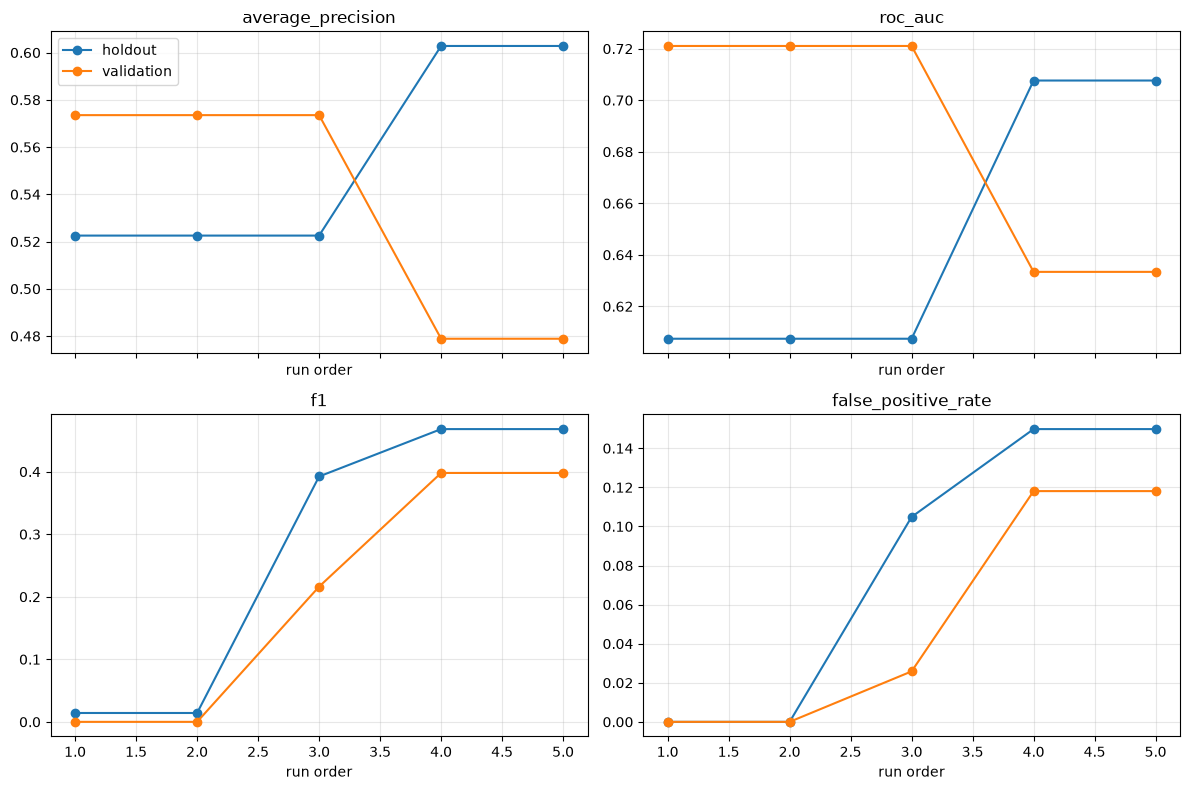

,run_id,created_at,split,model_key,split_column,missing_cutoff,feature_count,n_estimators,max_features,threshold_quantile,...,precision,recall,f1,false_positive_rate,run_dir,delta_vs_previous_best_average_precision,delta_vs_previous_best_roc_auc,delta_vs_previous_best_f1,delta_vs_previous_best_recall,delta_vs_previous_best_false_positive_rate
0,run_20260626_120251,2026-06-26T12:02:51,validation,split_time_based|0.3|300|0.8|0.95,split_time_based,0.3,112,300,0.8,0.95,...,0.000000,0.000000,0.000000,0.000000,C:\project3.0_2\data\processed\ml_baseline\run...,NaN,NaN,NaN,NaN,NaN
1,run_20260626_120251,2026-06-26T12:02:51,holdout,split_time_based|0.3|300|0.8|0.95,split_time_based,0.3,112,300,0.8,0.95,...,1.000000,0.007143,0.014184,0.000000,C:\project3.0_2\data\processed\ml_baseline\run...,NaN,NaN,NaN,NaN,NaN
2,run_20260626_123431,2026-06-26T12:34:31,validation,split_time_based|0.3|300|0.8|0.95,split_time_based,0.3,112,300,0.8,0.95,...,0.000000,0.000000,0.000000,0.000000,C:\project3.0_2\data\processed\ml_baseline\run...,NaN,NaN,NaN,NaN,NaN
3,run_20260626_123431,2026-06-26T12:34:31,holdout,split_time_based|0.3|300|0.8|0.95,split_time_based,0.3,112,300,0.8,0.95,...,1.000000,0.007143,0.014184,0.000000,C:\project3.0_2\data\processed\ml_baseline\run...,NaN,NaN,NaN,NaN,NaN
4,run_20260626_141134,2026-06-26T14:11:34,validation,split_time_based|0.3|300|0.8|0.8,split_time_based,0.3,112,300,0.8,0.80,...,0.695652,0.128000,0.216216,0.025830,C:\project3.0_2\data\processed\ml_baseline\run...,0.000000,0.000000,2.162162e-01,1.280000e-01,0.025830
5,run_20260626_141134,2026-06-26T14:11:34,holdout,split_time_based|0.3|300|0.8|0.8,split_time_based,0.3,112,300,0.8,0.80,...,0.594203,0.292857,0.392344,0.104869,C:\project3.0_2\data\processed\ml_baseline\run...,0.000000,0.000000,3.781601e-01,2.857143e-01,0.104869
6,run_20260626_144708,2026-06-26T14:47:08,validation,split_time_based|0.4|300|1.0|0.8,split_time_based,0.4,130,300,1.0,0.80,...,0.549296,0.312000,0.397959,0.118081,C:\project3.0_2\data\processed\ml_baseline\run...,-0.094661,-0.087675,1.817430e-01,1.840000e-01,0.118081
7,run_20260626_144708,2026-06-26T14:47:08,holdout,split_time_based|0.4|300|1.0|0.8,split_time_based,0.4,130,300,1.0,0.80,...,0.578947,0.392857,0.468085,0.149813,C:\project3.0_2\data\processed\ml_baseline\run...,0.080274,0.100214,7.574061e-02,1.000000e-01,0.149813
8,run_20260626_150028,2026-06-26T15:00:28,validation,split_time_based|0.4|300|1.0|0.8,split_time_based,0.4,130,300,1.0,0.80,...,0.549296,0.312000,0.397959,0.118081,C:\project3.0_2\data\processed\ml_baseline\run...,-0.094661,-0.087675,0.000000e+00,0.000000e+00,0.118081
9,run_20260626_150028,2026-06-26T15:00:28,holdout,split_time_based|0.4|300|1.0|0.8,split_time_based,0.4,130,300,1.0,0.80,...,0.578947,0.392857,0.468085,0.149813,C:\project3.0_2\data\processed\ml_baseline\run...,0.000000,0.000000,5.551115e-17,5.551115e-17,0.149813


이번 실행 저장 폴더: C:\project3.0_2\data\processed\ml_baseline\runs\run_20260626_150028
누적 이력: C:\project3.0_2\data\processed\ml_baseline\anomaly_run_history.csv
추이 그래프: C:\project3.0_2\data\processed\ml_baseline\anomaly_run_history_plot.png


In [8]:
from datetime import datetime
import shutil

import matplotlib.pyplot as plt

RUN_ID = datetime.now().strftime("run_%Y%m%d_%H%M%S")
RUN_DIR = OUT_DIR / "runs" / RUN_ID
RUN_MODEL_DIR = RUN_DIR / "models"
RUN_DIR.mkdir(parents=True, exist_ok=True)
RUN_MODEL_DIR.mkdir(parents=True, exist_ok=True)

run_files = [
    OUT_DIR / "anomaly_experiment_results.csv",
    OUT_DIR / "anomaly_model_metrics.csv",
    OUT_DIR / "anomaly_baseline_scores.csv",
    OUT_DIR / "anomaly_selected_features.csv",
]
for src in run_files:
    if src.exists():
        shutil.copy2(src, RUN_DIR / src.name)
        shutil.copy2(src, OUT_DIR / f"{src.stem}_{RUN_ID}{src.suffix}")

for src in sorted(MODEL_DIR.glob("*")):
    if src.is_file():
        shutil.copy2(src, RUN_MODEL_DIR / src.name)

history_path = OUT_DIR / "anomaly_run_history.csv"
history_plot_path = OUT_DIR / "anomaly_run_history_plot.png"

history_rows = []
for row in selected_summary.to_dict(orient="records"):
    history_rows.append({
        "run_id": RUN_ID,
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "split": row.get("split"),
        "model_key": row.get("model_key"),
        "split_column": row.get("split_column"),
        "missing_cutoff": row.get("missing_cutoff"),
        "feature_count": row.get("feature_count"),
        "n_estimators": row.get("n_estimators"),
        "max_features": row.get("max_features"),
        "threshold_quantile": row.get("threshold_quantile"),
        "threshold": row.get("threshold"),
        "average_precision": row.get("average_precision"),
        "roc_auc": row.get("roc_auc"),
        "precision": row.get("precision"),
        "recall": row.get("recall"),
        "f1": row.get("f1"),
        "false_positive_rate": row.get("false_positive_rate"),
        "run_dir": str(RUN_DIR),
    })

new_history = pd.DataFrame(history_rows)
if history_path.exists():
    previous_history = pd.read_csv(history_path)
    for metric in ["average_precision", "roc_auc", "f1", "recall", "false_positive_rate"]:
        previous_best = previous_history.groupby("split")[metric].max().to_dict() if metric != "false_positive_rate" else previous_history.groupby("split")[metric].min().to_dict()
        new_history[f"delta_vs_previous_best_{metric}"] = new_history.apply(
            lambda row: row[metric] - previous_best.get(row["split"], np.nan), axis=1
        )
    history = pd.concat([previous_history, new_history], ignore_index=True)
else:
    for metric in ["average_precision", "roc_auc", "f1", "recall", "false_positive_rate"]:
        new_history[f"delta_vs_previous_best_{metric}"] = np.nan
    history = new_history
history.to_csv(history_path, index=False)

plot_df = history[history["split"].isin(["validation", "holdout"])].copy()
plot_df["run_order"] = pd.factorize(plot_df["run_id"])[0] + 1

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
metrics_to_plot = ["average_precision", "roc_auc", "f1", "false_positive_rate"]
for ax, metric in zip(axes.ravel(), metrics_to_plot):
    for split_name, split_df in plot_df.groupby("split"):
        ax.plot(split_df["run_order"], split_df[metric], marker="o", label=split_name)
    ax.set_title(metric)
    ax.set_xlabel("run order")
    ax.grid(True, alpha=0.3)
axes[0, 0].legend()
fig.tight_layout()
fig.savefig(history_plot_path, dpi=160)
plt.show()

display(history.tail(10))
print("이번 실행 저장 폴더:", RUN_DIR)
print("누적 이력:", history_path)
print("추이 그래프:", history_plot_path)